# V3.6 — Char 'alligator' crackle (derived)  **TIER 3 / char texture**

**Claim (pre-registered).** The char crack network (`nebula.geometry.char_texture`) is DERIVED from the char shrinkage state, not painted: the polygonal **cell size follows the thickness law** (spacing ∝ char depth — thicker char → bigger scales), crack **depth grows with χ**, and cracks appear only on the **charred** surface. It is exported as a displacement/normal/AO map.

**Why load-bearing.** Char's distinctive alligator pattern is a defining 'it's really burnt' cue; deriving it from the shrinkage physics (not an authored texture) is causal fidelity for the surface.

**Independent oracle.** `shrinkage_crack_ref.py` — the mud-crack / thermal-crack thickness law (spacing ∝ layer thickness, cell area ∝ thickness²) + an FFT cell-size estimator independent of the generator.

| # | Metric | Threshold |
|---|---|---|
| C1 | alligator cell size vs char depth (measured FFT cell vs oracle prediction) | monotone↑ AND rel error < 0.2 |
| C2 | crack depth grows with char fraction χ | monotone↑ |
| C3 | cracks only on charred surface (unburnt displacement) | = 0 on unburnt AND > 0 on char |
| C4 | determinism: identical crackle on re-evaluation | identical |

In [1]:
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
ROOT = pathlib.Path.cwd().resolve()
while ROOT.name and not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src' / 'implementation'))
sys.path.insert(0, str(ROOT / 'src' / 'verification' / 'oracles'))
from nebula.operators.growth import grow_tree, GrowthParams
from nebula.geometry import char_texture as ct
from nebula.geometry.mesh_export import tube_mesh
import shrinkage_crack_ref as sc
np.seterr(all='ignore')
R = {}
print('char_texture + shrinkage-crack oracle loaded')

Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 4090" (24 GiB, sm_89, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.14.0


char_texture + shrinkage-crack oracle loaded


In [2]:
# C1 thickness law: measured alligator-cell size ∝ char depth, matching the oracle prediction
depths = [0.004, 0.006, 0.010, 0.016]; meas = []; pred = []
fields = {}
for h in depths:
    fld = ct.crack_field_2d(160, h, world_size=1.0, seed=7); fields[h]=fld
    meas.append(sc.measure_cell_size(fld, spacing_px=1.0/160)); pred.append(float(sc.crack_spacing(h)))
meas = np.array(meas); pred = np.array(pred)
R['C1_mono'] = bool(np.all(np.diff(meas)>0)); R['C1_relerr'] = float(np.max(np.abs(meas-pred)/pred))
print(f'depth {depths}')
print(f'predicted spacing {np.round(pred,3).tolist()}')
print(f'measured  cell    {np.round(meas,3).tolist()}')
print(f"C1 monotone {R['C1_mono']}, max rel error {R['C1_relerr']:.2f} (<0.2)")

depth [0.004, 0.006, 0.01, 0.016]
predicted spacing [0.024, 0.036, 0.06, 0.096]
measured  cell    [0.024, 0.036, 0.059, 0.1]
C1 monotone True, max rel error 0.04 (<0.2)


In [3]:
# C2/C3/C4 on a tree (charred base)
tree = grow_tree(seed=7, gp=GrowthParams(dim=3)); verts,faces,vnode = tube_mesh(tree)
z = verts[:,2]; chi = np.where(z < z.min()+0.35*np.ptp(z), 0.9, 0.0)
rel = ct.char_relief(tree, verts, vnode, chi, seed=7)
cd = ct.crack_depth(np.array([0.0,0.3,0.6,1.0]), 0.01)
R['C2_mono'] = bool(np.all(np.diff(cd)>=0) and cd[-1]>cd[0])
R['C3_unburnt'] = float(rel['displacement'][chi==0].max()); R['C3_char'] = float((rel['fissure'][chi>0]>0).mean())
rel2 = ct.char_relief(tree, verts, vnode, chi, seed=7)
R['C4_det'] = bool(np.array_equal(rel['displacement'], rel2['displacement']))
print(f"C2 crack depth vs χ {np.round(cd,4).tolist()} monotone {R['C2_mono']}")
print(f"C3 unburnt disp {R['C3_unburnt']:.4f} (=0); charred cracked frac {R['C3_char']:.2f}")
print(f"C4 determinism {R['C4_det']}")

C2 crack depth vs χ [0.0, 0.003, 0.006, 0.01] monotone True
C3 unburnt disp 0.0000 (=0); charred cracked frac 0.75
C4 determinism True


saved results/V3_6_char_crack.png

V3.6 PASS — the char crackle cell size follows the thickness law; derived, char-only, exportable.


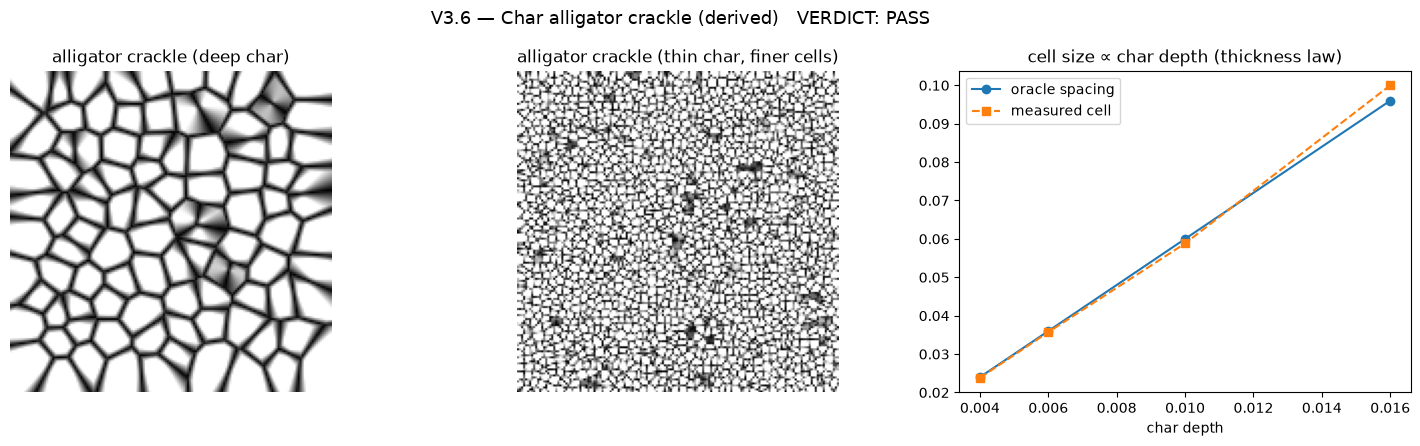

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax[0].imshow(fields[0.016], cmap='gray_r'); ax[0].set_title('alligator crackle (deep char)'); ax[0].axis('off')
ax[1].imshow(fields[0.004], cmap='gray_r'); ax[1].set_title('alligator crackle (thin char, finer cells)'); ax[1].axis('off')
ax[2].plot(depths, pred, 'o-', label='oracle spacing'); ax[2].plot(depths, meas, 's--', label='measured cell')
ax[2].set_title('cell size ∝ char depth (thickness law)'); ax[2].set_xlabel('char depth'); ax[2].legend()
C1=R['C1_mono'] and R['C1_relerr']<0.2; C2=R['C2_mono']; C3=R['C3_unburnt']==0 and R['C3_char']>0; C4=R['C4_det']
allpass=C1 and C2 and C3 and C4
fig.suptitle(f'V3.6 — Char alligator crackle (derived)   VERDICT: {"PASS" if allpass else "FAIL"}', fontsize=13)
fig.tight_layout(); fig.savefig('results/V3_6_char_crack.png', dpi=110, bbox_inches='tight')
print('saved results/V3_6_char_crack.png')
assert allpass, 'V3.6 criteria not all met'
print('\nV3.6 PASS — the char crackle cell size follows the thickness law; derived, char-only, exportable.')